# EEG TRF Analysis: Speech and Music Listening
### Reproduction of Simon et al. (2024) using Eelbrain
#### Chan Myae Yin Aung | Supervisor: Dr Adele Simon | UCL | 2025

[Direct Link to Paper](https://onlinelibrary.wiley.com/doi/pdf/10.1111/ejn.16265)
Title: Cortical linear encoding and decoding of sounds: Similarities and differences between naturalistic speech and music listening

## Overview
This notebook reproduces the condition-level TRF (Temporal Response Function) analysis from Simon et al. (2024) using Python and Eelbrain, as an alternative to the original MATLAB/mTRF implementation.

Forward models (encoding models) are estimated using Eelbrain's boosting algorithm, predicting EEG responses from the acoustic envelope of each stimulus condition. Three levels of cross-validation are compared: **k=4, k=10, and k=20** — to check whether increasing k improves prediction accuracy. Results were qualitatively unchanged across all three (mean r differed by < 0.002).

**Five conditions:** Music Cello (mc), Music Danish (md), Music Finnish (mf), Speech Danish (sd), Speech Finnish (sf)

**Data source:** Preprocessed EEG (.mat files) from Zenodo (DOI: 10.5281/zenodo.7500806)

> **To adapt for a new dataset:** Update the file paths in the setup section and adjust `SFREQ`, `N_TIMES`, and electrode coordinates accordingly.

In [ ]:
# importing important libraries
from eelbrain import *
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.io import loadmat

## Loading MATLAB data into Python (Eelbrain package)

In [ ]:
# ── File paths 
DATA_ROOT = Path(r"C:\Users\chanm\eelbrain\Processed")    # folder containing .mat condition files
figures_path = Path(r"C:\Users\chanm\eelbrain\figures")   # output folder for figures

In [ ]:
# creating the Sensor dimension from the electrode positions
ced = pd.read_csv(r"C:\Users\chanm\eelbrain\electrodes_locations.ced",
                  sep='\t'  # the .ced file is tab-separated
                 )

names = ced['labels'].tolist()                          # electrode names as a Python list
locs = ced[['Y', 'X', 'Z']].values.astype(float)       # 3D electrode coordinates
# Note: Y and X are swapped as it was written in this order in the original .ced file
sensor = Sensor(locs, names=names)
sensor.set_adjacency(connect_dist=1.7)                 # connect sensors within 1.7 units as neighbours

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


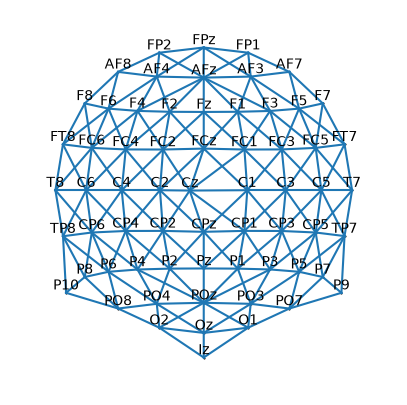

In [4]:
# plotting the sensor positions 
p = plot.SensorMap(sensor, adjacency=True)

In [5]:
# creating constants to make the time dimension 
SFREQ = 128 # Hz
TSTEP = 1/SFREQ # time step 

# creating the Time dimension 
N_TIMES = 7680 # from EEG 
time = UTS(0, TSTEP, N_TIMES)

## Loading Files from MatLab

In [6]:
# making a dictionary for all conditions
conditions = {'mc': 'Data_Music_Cello.mat',
              'md': 'Data_Music_Danish.mat',
              'mf': 'Data_Music_Finnish.mat',
              'sd': 'Data_Speech_Danish.mat',
              'sf': 'Data_Speech_Finnish.mat',
}

# making a dictionary to store all 5 datasets 
ds_all = {}

# looping through each condition
for con, filename in conditions.items():
    mat = loadmat(DATA_ROOT / filename)
    data = mat[filename.replace('.mat', '')]

    rows = [] 
    for i in range(data.shape[1]): # looping through all the trials in each dataset 
        trial = data[0,i] # extracting details for each trial/row (data is a 2D array with shape (1,87))

        eeg_arr = trial['EEG_processed'] # eeg component (64, 7680)
        env_arr = trial['Audio_Envelope'][:,0] # the original envelope column is 2D (7680x1) ->  extracts all the content from the first column and convert it to 1D (7680,)

        eeg_ndvar = NDVar(eeg_arr, (sensor, time), name='eeg')
        env_ndvar = NDVar(env_arr, (time), name='envelope')
        rows.append({
                'participant': int(trial['Participant'].flat[0]), # since MATLAB stores these columns as nested array -> need to flatten them out 
                'trial': int(trial['Trial'].flat[0]),
                'audio_name': str(trial['Audio_Name'].flat[0]),
                'engagement': float(trial['Engagement'].flat[0]),
                'familiarity': float(trial['Familiarity'].flat[0]),
                'duration': N_TIMES/SFREQ,
                'eeg': eeg_ndvar,
                'envelope': env_ndvar,
            })

    # converting to Eelbrain dataset
    ds = Dataset({
        'participant': Var([r['participant'] for r in rows]),
        'trial':       Var([r['trial']       for r in rows]),
        'audio_name':  Factor([r['audio_name']  for r in rows]),
        'engagement':  Var([r['engagement']  for r in rows]),
        'familiarity': Var([r['familiarity'] for r in rows]),
        'duration':    Var([r['duration']    for r in rows]),
        'envelope':    combine([r['envelope']   for r in rows]), # combines the NDVars components of envelope
        'eeg':         combine([r['eeg']        for r in rows]),
    })

    ds_all[con] = ds

# extracting each condition into its own variable 
ds_mc = ds_all['mc']
ds_md = ds_all['md']
ds_mf = ds_all['mf']
ds_sd = ds_all['sd']
ds_sf = ds_all['sf']

In [7]:
ds_mc.head()

#,participant,trial,audio_name,engagement,familiarity,duration
0,1,12,5_MC.,73.128,27.495,60
1,1,15,4_MC.,71.789,20.594,60
2,1,16,1_MC.,74.364,9.9837,60
3,1,18,3_MC.,84.459,90.124,60
4,1,23,2_MC.,77.969,79.617,60
5,2,14,3_MC.,90.124,90,60
6,2,16,4_MC.,90,10,60
7,2,17,5_MC.,90,90,60
8,2,23,1_MC.,90,44.182,60
9,2,28,2_MC.,90,10,60


In [8]:
ds_md.head()

#,participant,trial,audio_name,engagement,familiarity,duration
0,1,2,5_MD.,77.248,11.117,60
1,1,7,4_MD.,78.793,10,60
2,1,17,2_MD.,79.514,82.501,60
3,1,20,3_MD.,76.218,90,60
4,1,24,1_MD.,76.733,16.164,60
5,2,13,3_MD.,90,90,60
6,2,15,4_MD.,90,10,60
7,2,22,2_MD.,90,10,60
8,2,30,5_MD.,90,90,60
9,3,2,5_MD.,90,69.419,60


In [9]:
ds_mf.head()

#,participant,trial,audio_name,engagement,familiarity,duration
0,1,10,2_MF.,71.274,61.385,60
1,1,19,3_MF.,69.316,64.063,60
2,1,22,1_MF.,81.883,10,60
3,1,25,4_MF.,78.484,10,60
4,1,27,5_MF.,71.583,20.388,60
5,2,10,1_MF.,90,69.522,60
6,2,12,5_MF.,90,90,60
7,2,19,4_MF.,90,10,60
8,2,26,3_MF.,90,90,60
9,3,1,5_MF.,90,10,60


In [10]:
ds_sd.head()

#,participant,trial,audio_name,engagement,familiarity,duration
0,1,4,3_SD.,76.321,67.771,60
1,1,21,1_SD.,75.703,50,60
2,1,29,2_SD.,66.638,50,60
3,1,30,5_SD.,70.347,50,60
4,2,18,5_SD.,90,10,60
5,2,24,4_SD.,90,10,60
6,2,27,3_SD.,90,10,60
7,2,29,2_SD.,90,10,60
8,3,3,1_SD.,89.712,90,60
9,3,7,3_SD.,89.197,89.094,60


In [11]:
ds_sf.head()

#,participant,trial,audio_name,engagement,familiarity,duration
0,1,5,4_SF.,61.179,0,60
1,1,8,3_SF.,77.454,10,60
2,1,11,1_SF.,50,6.0694,60
3,1,14,5_SF.,66.947,10,60
4,1,26,2_SF.,76.012,10,60
5,2,7,3_SF.,90,10,60
6,2,8,5_SF.,90,10,60
7,2,25,4_SF.,90,10,60
8,3,4,1_SF.,86.622,10.499,60
9,3,6,2_SF.,89.712,10.293,60


# Cello Music

## TRF analysis

### TRF Parameters (from Simon et al. 2024, Section 2.6)
- **τmin = −100 ms, τmax = 750 ms** — TRF time window
- **basis = 0.050** — 50ms Hamming windows for smoothing
- **test = True** — enables predictive power (r) and proportion explained

Three values of k are compared: **k=4, k=10, k=20** — to check whether more cross-validation folds improve prediction accuracy.

> **Note:** The paper used ridge regression (mTRF MATLAB toolbox). Eelbrain uses the boosting algorithm (coordinate descent with cross-validation-based early stopping) instead — results are comparable.

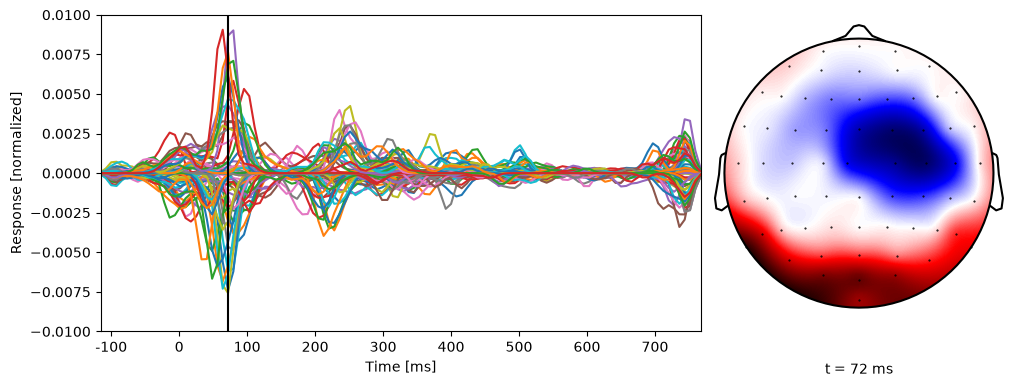

In [114]:
#estimating TRF and eeg using boosting + cross-validation
trf_mc = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_mc, basis=0.050, partitions=4, test=True)

#plotting the TRF
t = trf_mc.h.std('sensor').argmax('time') # finds the time point of max GFP (when TRF is strongest across all sensors) 
p = plot.TopoButterfly(trf_mc.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_cello_k4.png', dpi=300, bbox_inches='tight')

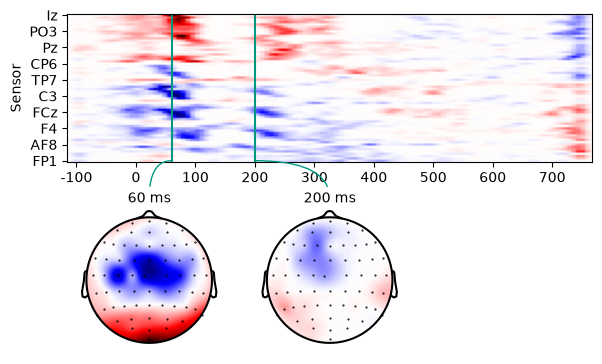

In [115]:
# visualising as topoarray (using time points from paper)
p = plot.TopoArray(trf_mc.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_cello_k4.png', dpi=300, bbox_inches='tight')

## Predictive Power and Correlation Coefficient

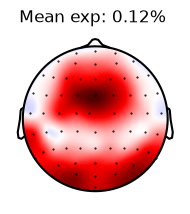

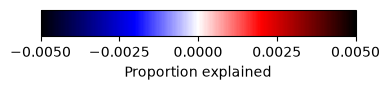

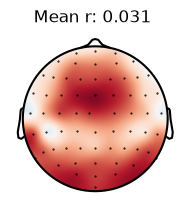

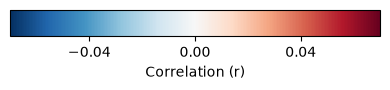

In [116]:
# plot the predictive power across sensors, including the average across all sensors in each figure title 
title = f"Mean exp: {trf_mc.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_mc.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_cello_k4.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_mc.r.mean('sensor'):.2}"
p = plot.Topomap(trf_mc.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_cello_k4.png', dpi=300, bbox_inches='tight')

### Interpreting Predictive Power and Correlation Coefficient
- **proportion_explained (R²):** How much of the EEG variance is explained by the TRF model
- **r (correlation coefficient):** Correlation between the predicted EEG and the actual EEG — this is what the paper calls 'EEG prediction accuracy'

**Comparison with paper (Music Cello, k=4):**
- Paper (MATLAB/ridge regression): prediction accuracy ≈ 0.030
- Python (Eelbrain/boosting): mean r ≈ 0.031
→ Results are comparable, confirming the analysis is reproducible across implementations.

### k=10

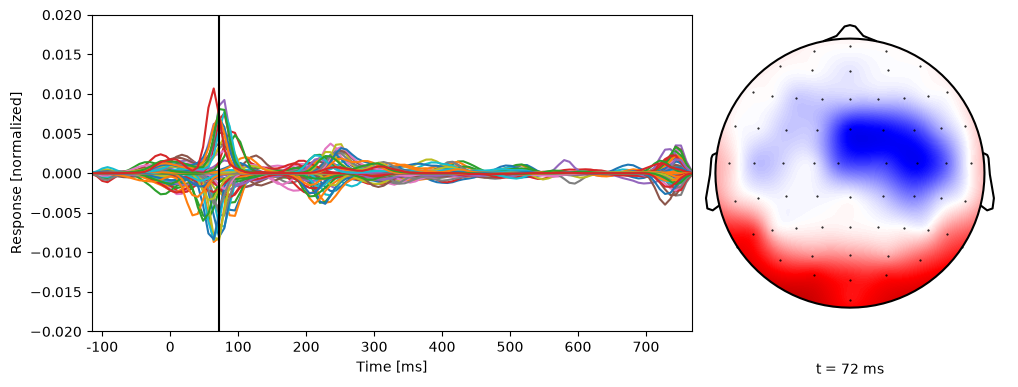

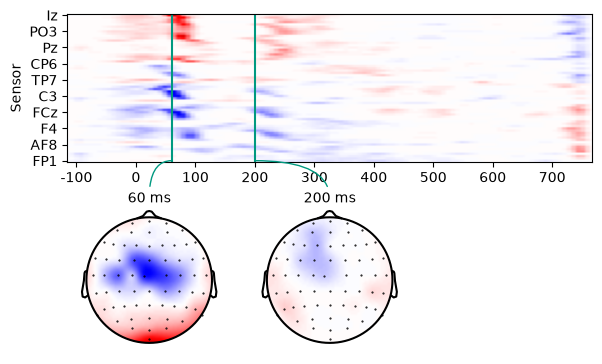

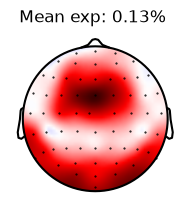

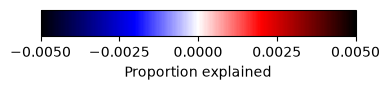

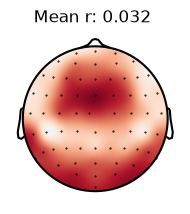

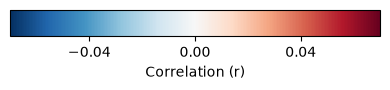

In [24]:
trf_mc = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_mc, basis=0.050, partitions=10, test=True)

#plotting the TRF
t = trf_mc.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_mc.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_cello_k10.png', dpi=300, bbox_inches='tight')

# visualising as topoarray (using time points from paper)
p = plot.TopoArray(trf_mc.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_cello_k10.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_mc.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_mc.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_cello_k10.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_mc.r.mean('sensor'):.2}"
p = plot.Topomap(trf_mc.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_cello_k10.png', dpi=300, bbox_inches='tight')

### k=20

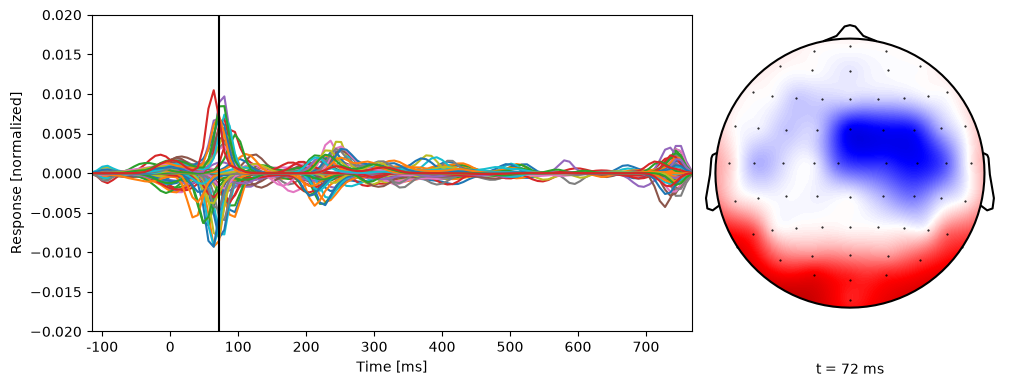

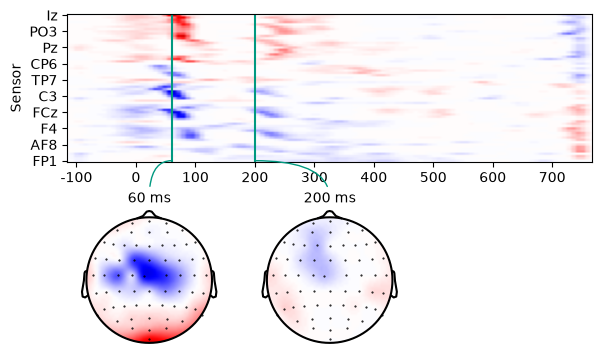

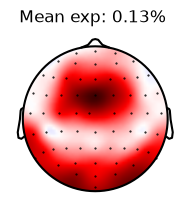

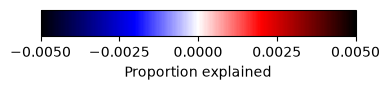

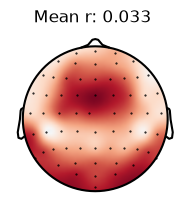

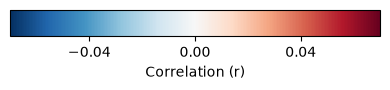

In [27]:
trf_mc = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_mc, basis=0.050, partitions=20, test=True)

#plotting the TRF
t = trf_mc.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_mc.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_cello_k20.png', dpi=300, bbox_inches='tight')

# visualising as topoarray (using time points from paper)
p = plot.TopoArray(trf_mc.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_cello_k20.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_mc.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_mc.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_cello_k20.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_mc.r.mean('sensor'):.2}"
p = plot.Topomap(trf_mc.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_cello_k20.png', dpi=300, bbox_inches='tight')

# Danish Music

## TRF analysis

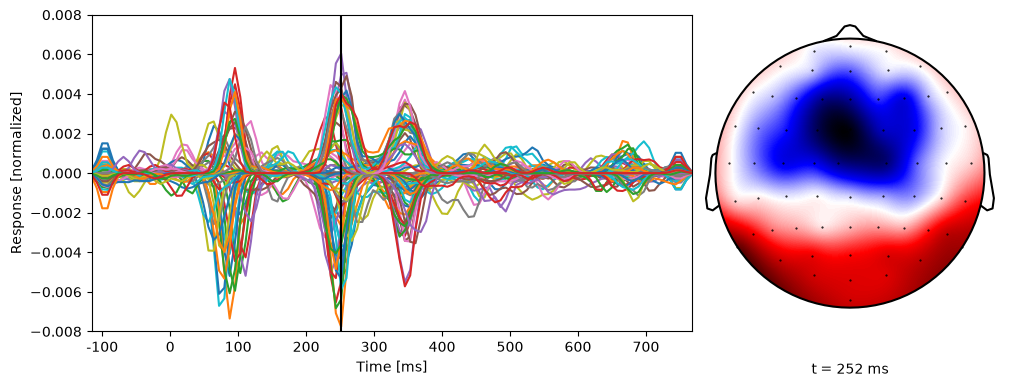

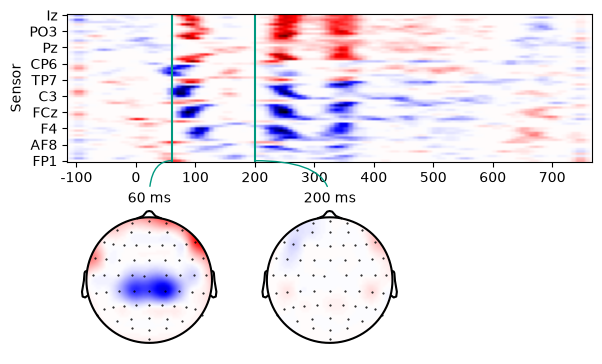

In [117]:
#estimating TRF and eeg using boosting + cross-validation
trf_md = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_md, basis=0.050, partitions=4, test=True)

#plotting the TRF
t = trf_md.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_md.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_danish_k4.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_md.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_danish_k4.png', dpi=300, bbox_inches='tight')

## Predictive Power and Correlation Coefficient

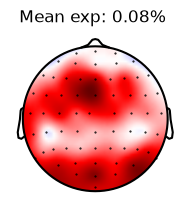

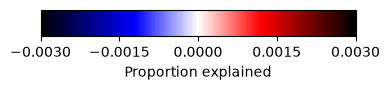

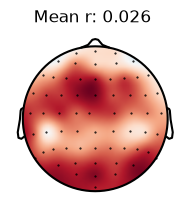

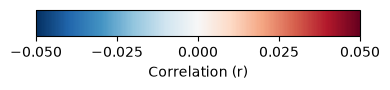

In [118]:
# plot the predictive power across sensors
title = f"Mean exp: {trf_md.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_md.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_danish_k4.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_md.r.mean('sensor'):.2}"
p = plot.Topomap(trf_md.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_danish_k4.png', dpi=300, bbox_inches='tight')

### k = 10

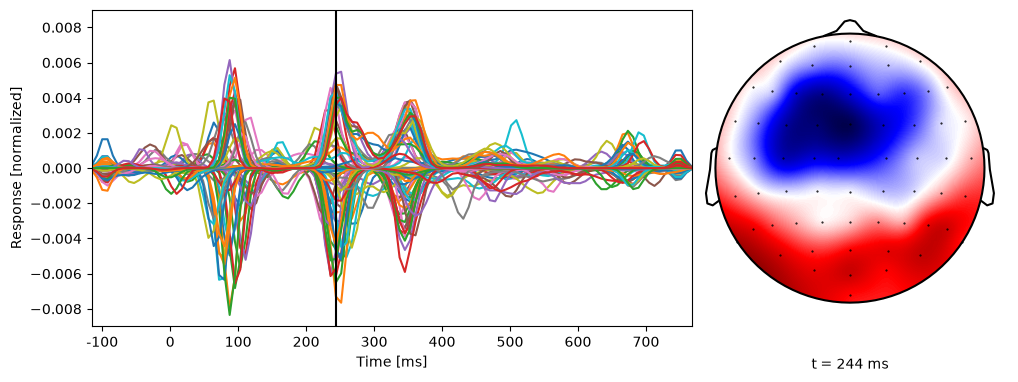

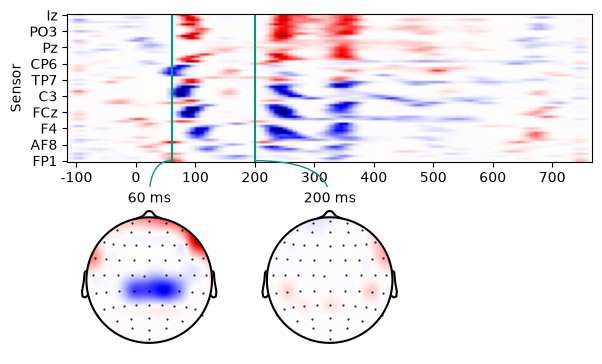

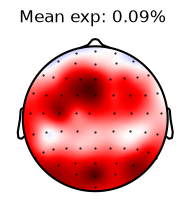

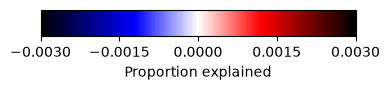

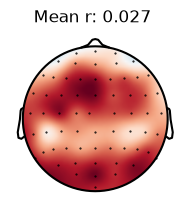

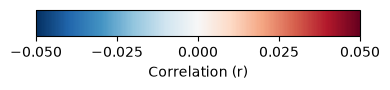

In [28]:
trf_md = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_md, basis=0.050, partitions=10, test=True)

#plotting the TRF
t = trf_md.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_md.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_danish_k10.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_md.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_danish_k10.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_md.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_md.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_danish_k10.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_md.r.mean('sensor'):.2}"
p = plot.Topomap(trf_md.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_danish_k10.png', dpi=300, bbox_inches='tight')

### k = 20

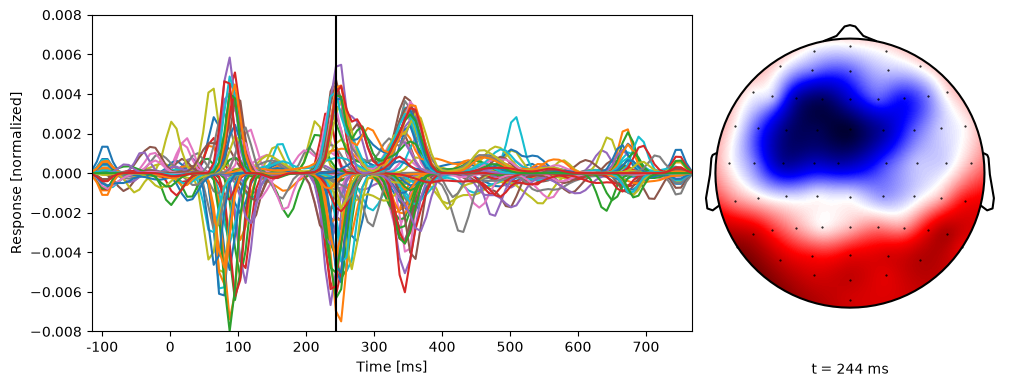

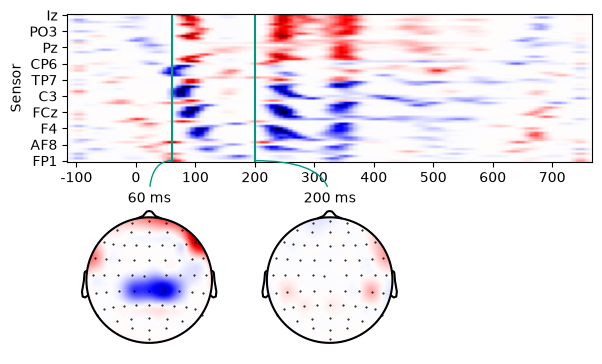

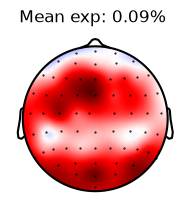

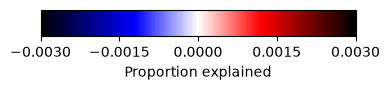

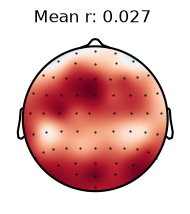

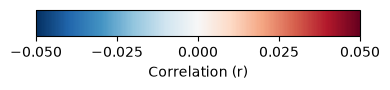

In [8]:
trf_md = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_md, basis=0.050, partitions=20, test=True)

#plotting the TRF
t = trf_md.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_md.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_danish_k20.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_md.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_danish_k20.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_md.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_md.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_danish_k20.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_md.r.mean('sensor'):.2}"
p = plot.Topomap(trf_md.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_danish_k20.png', dpi=300, bbox_inches='tight')

# Finnish Music

## TRF analysis

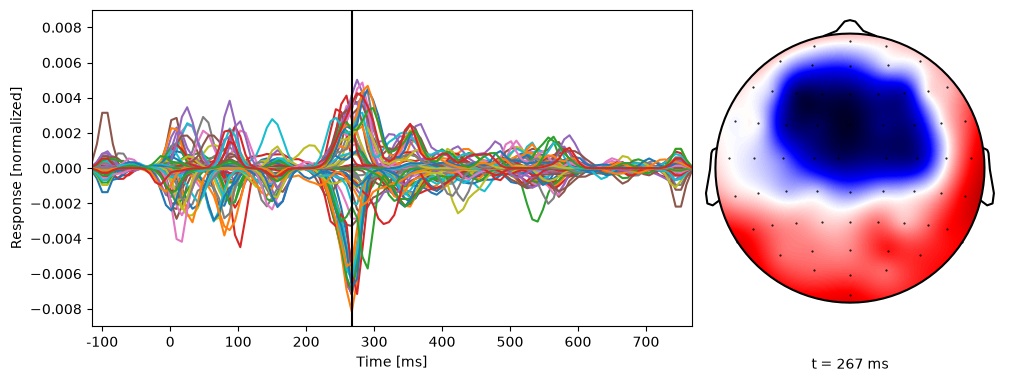

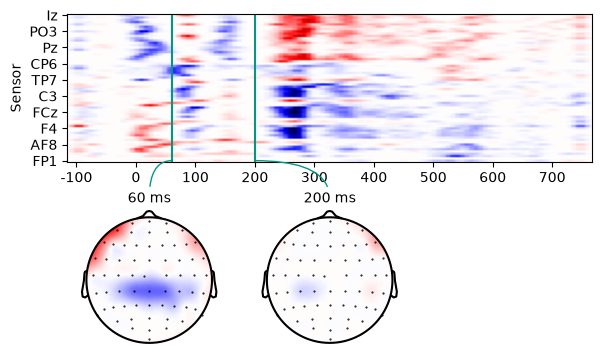

In [121]:
#estimating TRF and eeg using boosting + cross-validation
trf_mf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_mf, basis=0.050, partitions=4, test=True)

#plotting the TRF
t = trf_mf.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_mf.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_finnish_k4.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_mf.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_finnish_k4.png', dpi=300, bbox_inches='tight')

## Predictive Power and Correlation Coefficient

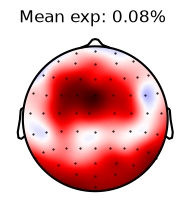

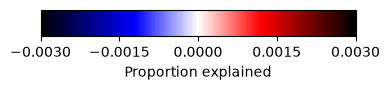

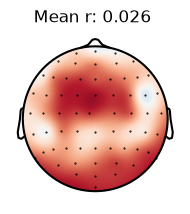

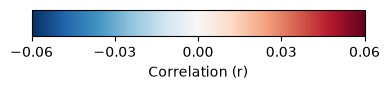

In [122]:
# plot the predictive power across sensors
title = f"Mean exp: {trf_mf.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_mf.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_finnish_k4.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_mf.r.mean('sensor'):.2}"
p = plot.Topomap(trf_mf.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_finnish_k4.png', dpi=300, bbox_inches='tight')

### k = 10

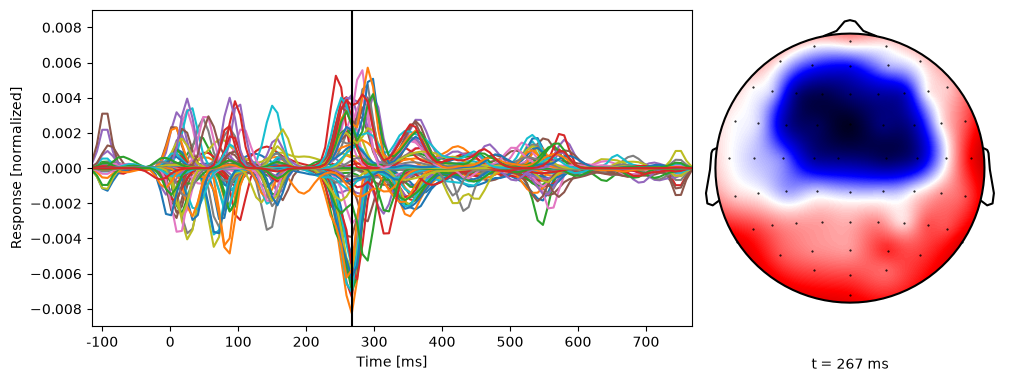

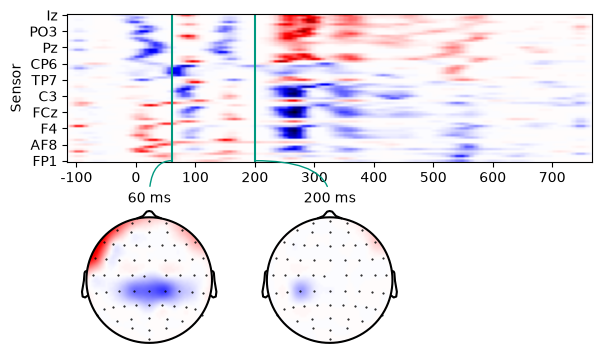

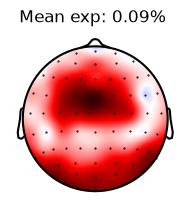

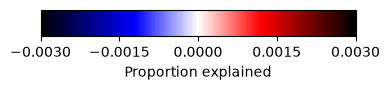

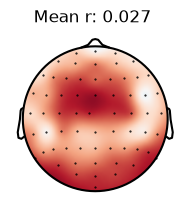

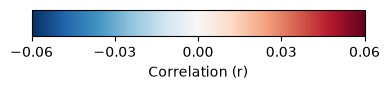

In [7]:
trf_mf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_mf, basis=0.050, partitions=10, test=True)

#plotting the TRF
t = trf_mf.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_mf.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_finnish_k10.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_mf.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_finnish_k10.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_mf.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_mf.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_finnish_k10.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_mf.r.mean('sensor'):.2}"
p = plot.Topomap(trf_mf.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_finnish_k10.png', dpi=300, bbox_inches='tight')

### k = 20

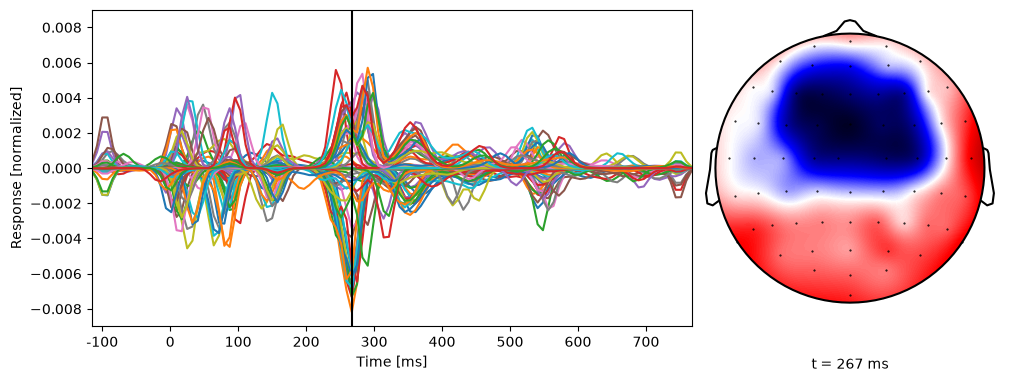

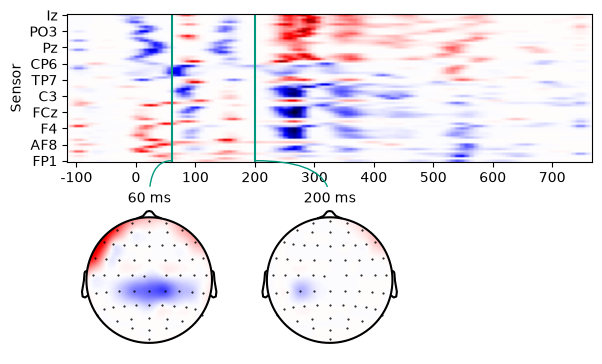

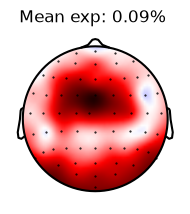

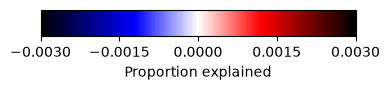

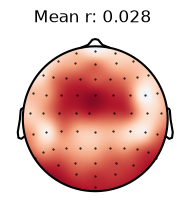

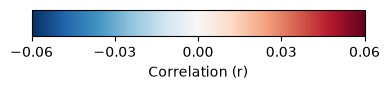

In [9]:
trf_mf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_mf, basis=0.050, partitions=20, test=True)

#plotting the TRF
t = trf_mf.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_mf.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_music_finnish_k20.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_mf.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_music_finnish_k20.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_mf.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_mf.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_music_finnish_k20.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_mf.r.mean('sensor'):.2}"
p = plot.Topomap(trf_mf.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_music_finnish_k20.png', dpi=300, bbox_inches='tight')

# Danish Speech

## TRF analysis

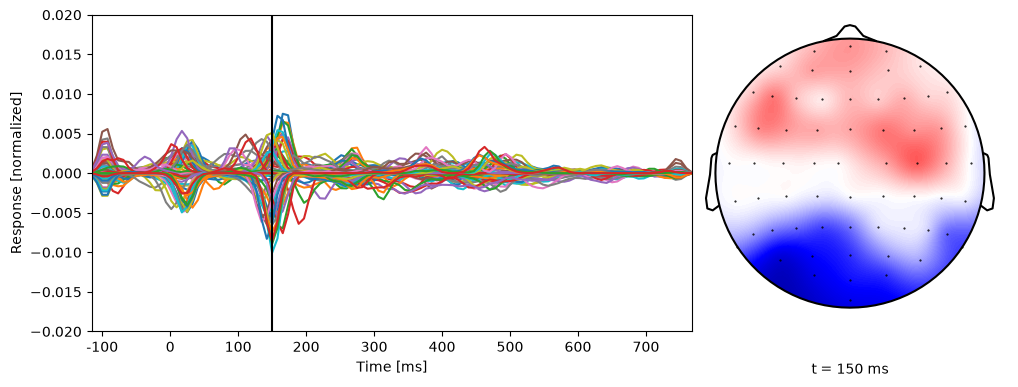

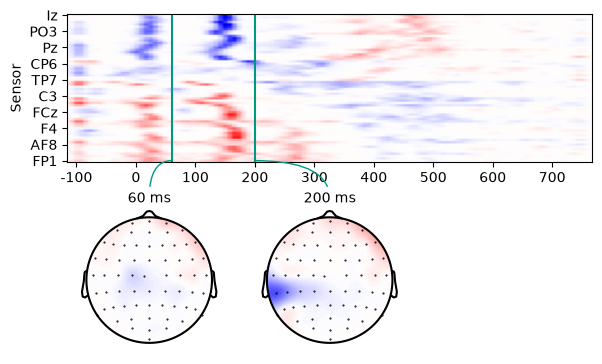

In [123]:
#estimating TRF and eeg using boosting + cross-validation
trf_sd = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_sd, basis=0.050, partitions=4, test=True)

#plotting the TRF
t = trf_sd.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_sd.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_speech_danish_k4.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_sd.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_speech_danish_k4.png', dpi=300, bbox_inches='tight')

## Predictive Power and Correlation Coefficient

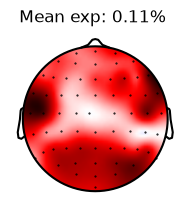

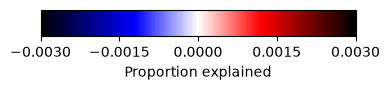

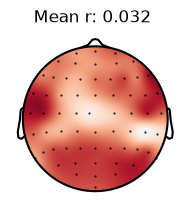

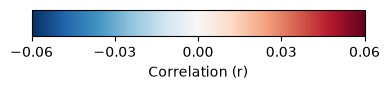

In [124]:
# plot the predictive power across sensors
title = f"Mean exp: {trf_sd.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_sd.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_speech_danish_k4.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_sd.r.mean('sensor'):.2}"
p = plot.Topomap(trf_sd.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_speech_danish_k4.png', dpi=300, bbox_inches='tight')

### k = 10

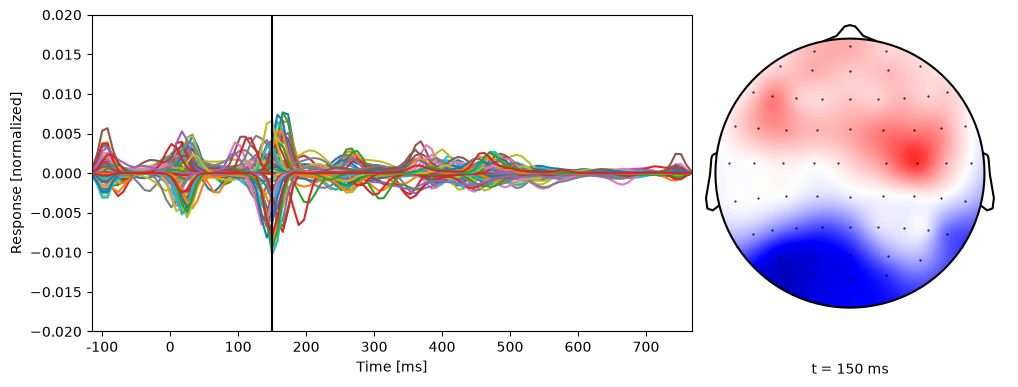

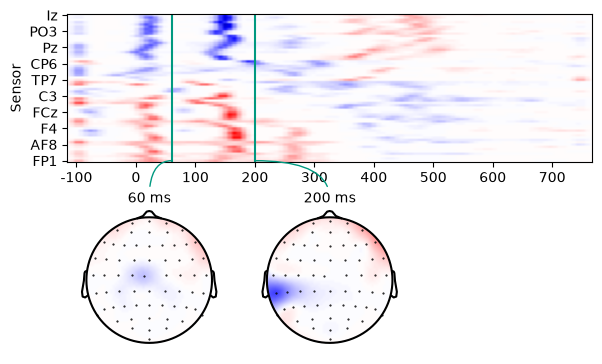

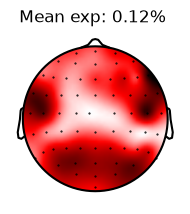

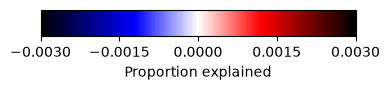

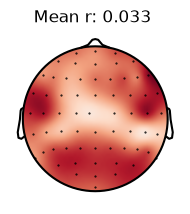

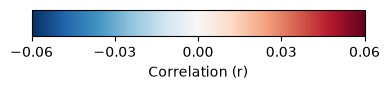

In [10]:
trf_sd = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_sd, basis=0.050, partitions=10, test=True)

#plotting the TRF
t = trf_sd.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_sd.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_speech_danish_k10.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_sd.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_speech_danish_k10.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_sd.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_sd.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_speech_danish_k10.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_sd.r.mean('sensor'):.2}"
p = plot.Topomap(trf_sd.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_speech_danish_k10.png', dpi=300, bbox_inches='tight')

### k = 20

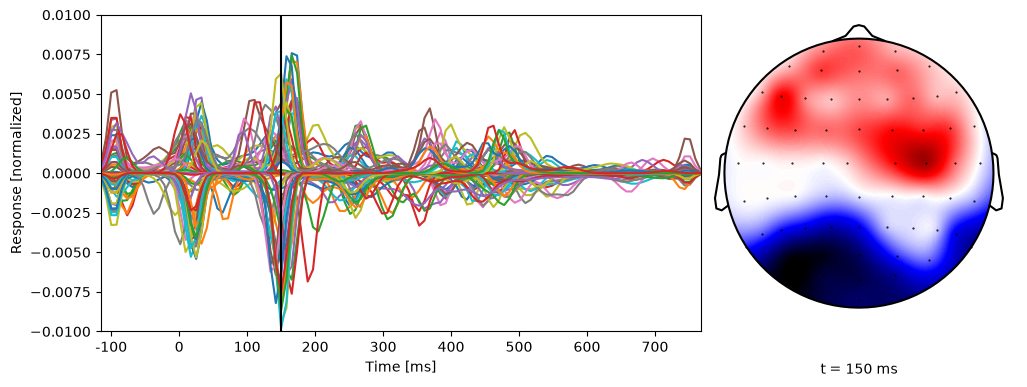

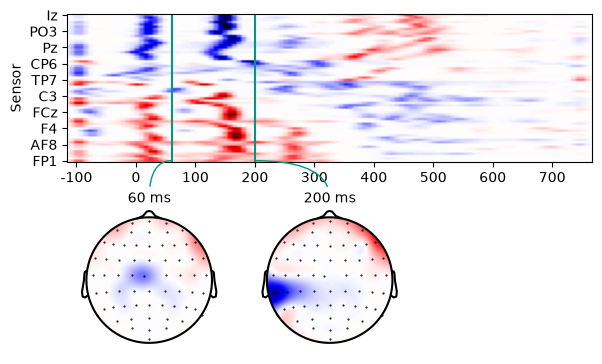

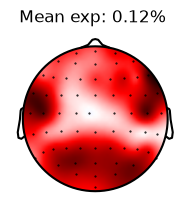

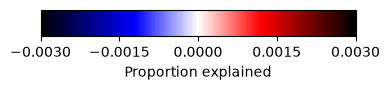

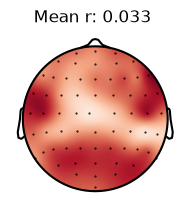

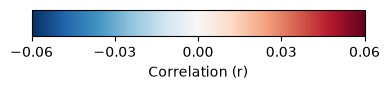

In [8]:
trf_sd = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_sd, basis=0.050, partitions=20, test=True)

#plotting the TRF
t = trf_sd.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_sd.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_speech_danish_k20.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_sd.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_speech_danish_k20.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors 
title = f"Mean exp: {trf_sd.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_sd.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_speech_danish_k20.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_sd.r.mean('sensor'):.2}"
p = plot.Topomap(trf_sd.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_speech_danish_k20.png', dpi=300, bbox_inches='tight')

# Finnish Speech

## TRF analysis

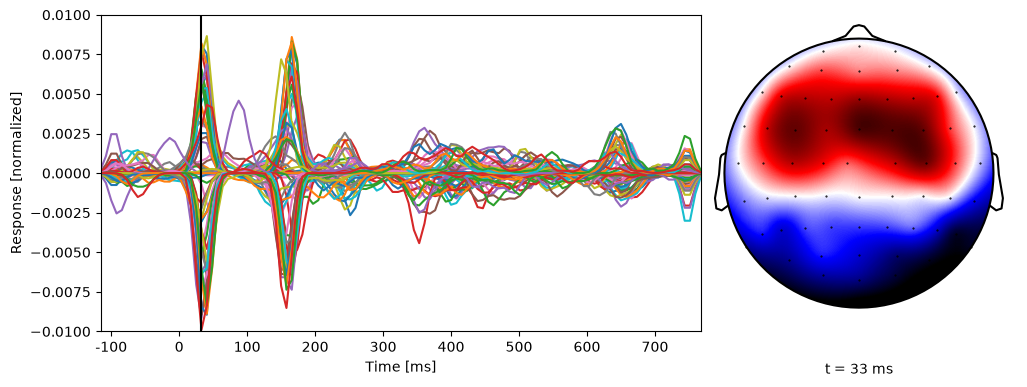

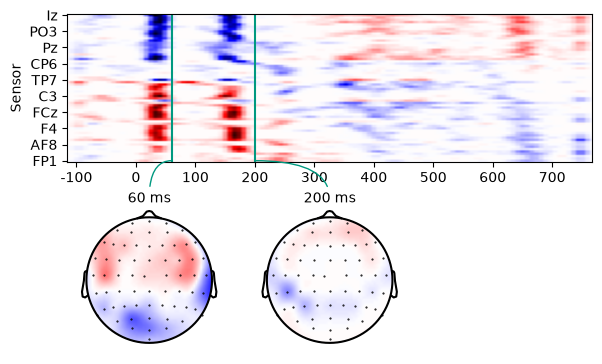

In [125]:
#estimating TRF and eeg using boosting + cross-validation
trf_sf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_sf, basis=0.050, partitions=4, test=True)

#plotting the TRF
t = trf_sf.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_sf.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_speech_finnish_k4.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_sf.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_speech_finnish_k4.png', dpi=300, bbox_inches='tight')

## Predictive Power and Correlation Coefficient

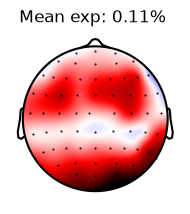

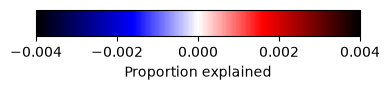

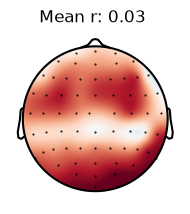

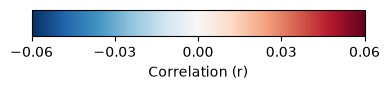

In [126]:
# plot the predictive power across sensors
title = f"Mean exp: {trf_sf.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_sf.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_speech_finnish_k4.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_sf.r.mean('sensor'):.2}"
p = plot.Topomap(trf_sf.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_speech_finnish_k4.png', dpi=300, bbox_inches='tight')

### k = 10

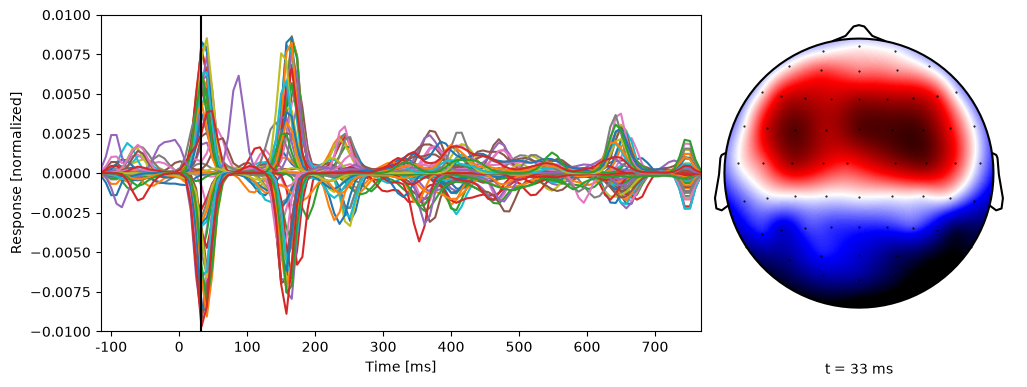

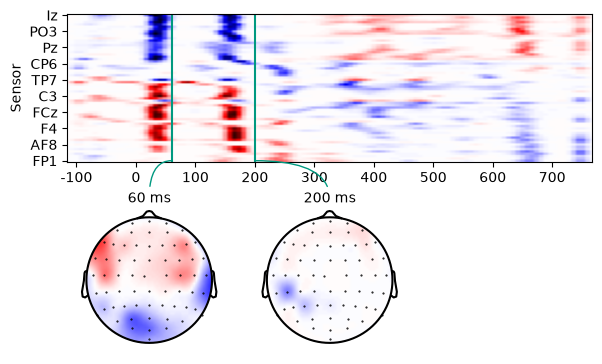

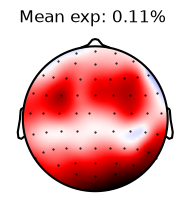

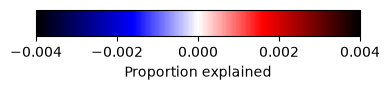

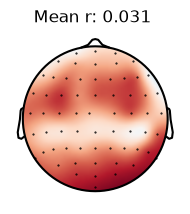

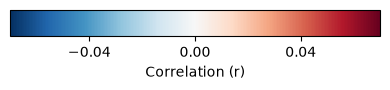

In [7]:
trf_sf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_sf, basis=0.050, partitions=10, test=True)

#plotting the TRF
t = trf_sf.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_sf.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_speech_finnish_k10.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_sf.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_speech_finnish_k10.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_sf.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_sf.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_speech_finnish_k10.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_sf.r.mean('sensor'):.2}"
p = plot.Topomap(trf_sf.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_speech_finnish_k10.png', dpi=300, bbox_inches='tight')

### k = 20

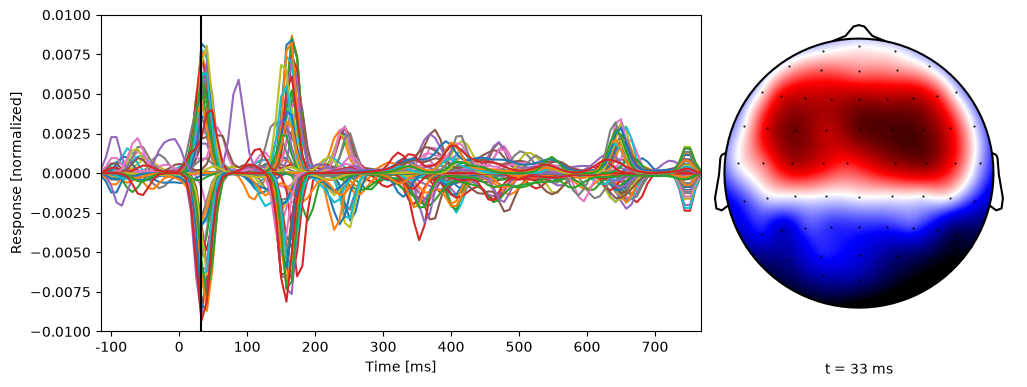

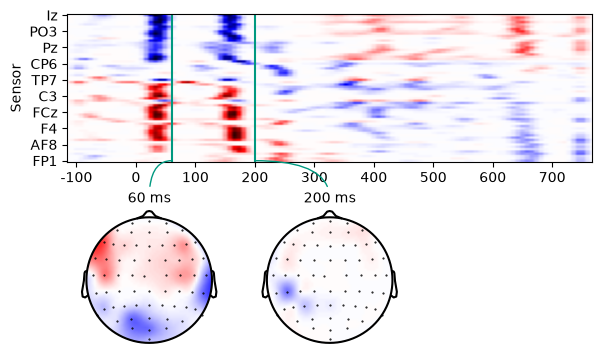

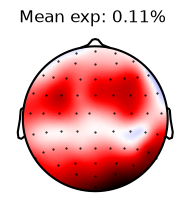

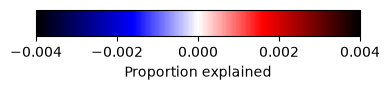

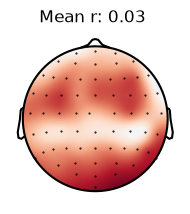

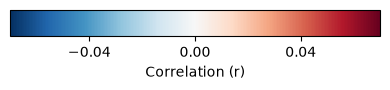

In [9]:
trf_sf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_sf, basis=0.050, partitions=20, test=True)

#plotting the TRF
t = trf_sf.h.std('sensor').argmax('time') 
p = plot.TopoButterfly(trf_sf.h, t=t, w=10, h=4, clip='circle')
p.figure.savefig(figures_path / 'trf_speech_finnish_k20.png', dpi=300, bbox_inches='tight')

# visualising as topoarray 
p = plot.TopoArray(trf_sf.h, t=[0.060, 0.200, None], w=6, h=4, clip='circle')
p.figure.savefig(figures_path / 'topoarray_speech_finnish_k20.png', dpi=300, bbox_inches='tight')

# plot the predictive power across sensors
title = f"Mean exp: {trf_sf.proportion_explained.mean('sensor'):.2%}" 
p = plot.Topomap(trf_sf.proportion_explained, clip='circle', title=title)
pcb = p.plot_colorbar('Proportion explained') 
p.figure.savefig(figures_path / 'pp_speech_finnish_k20.png', dpi=300, bbox_inches='tight')

# plot the mean prediction accuracy
title = f"Mean r: {trf_sf.r.mean('sensor'):.2}"
p = plot.Topomap(trf_sf.r, clip='circle', title=title)
pcb = p.plot_colorbar('Correlation (r)')
p.figure.savefig(figures_path / 'mean_r_speech_finnish_k20.png', dpi=300, bbox_inches='tight')

# Comparison with paper
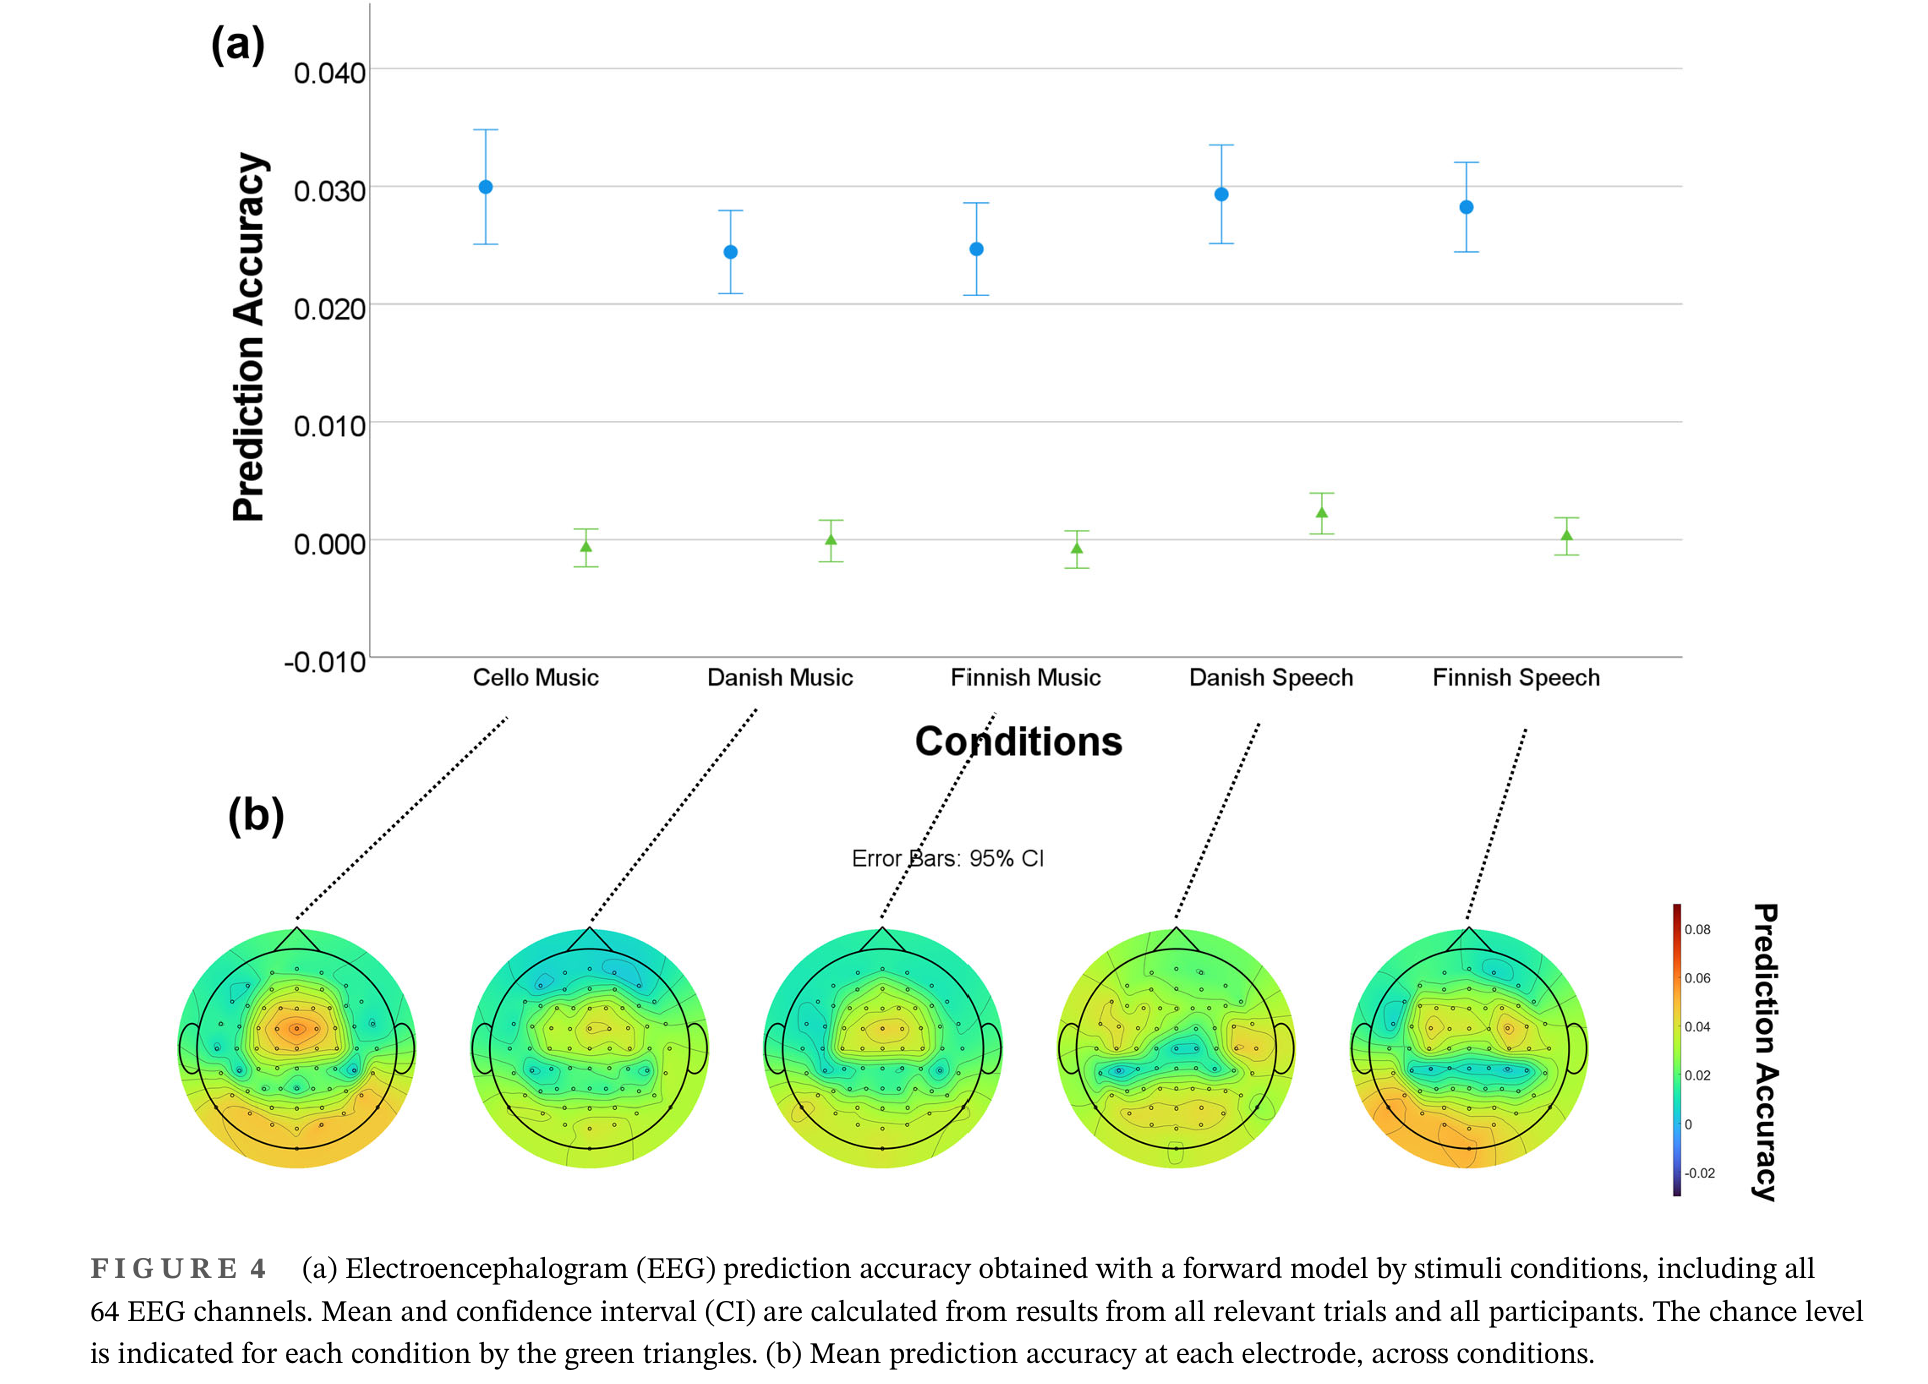